# Data preprocessing

Real-world data rarely arrive in exactly the form that a machine-learning algorithm needs. Some variables are categorical, some numerical, different features may use very different scales, and some features may contain little useful information or duplicate information contained elsewhere.

**Preprocessing** is the set of decisions and transformations that turn the original data into a representation that is suitable for modelling.

In this chapter, we focus on five questions:

1. How do we understand the variables in a dataset?
2. How should categorical features be represented?
3. When and why should numerical features be scaled?
4. Why might we remove features?
5. How do we preprocess data without leaking information from the test set?

The goal is not to memorise a collection of preprocessing functions. Instead, we will connect each preprocessing choice to the type of data and the model that will use it.

## 1. Understanding your data

Before transforming anything, we first need to understand what each row and column represents.

A typical supervised-learning dataset can be thought of as:

- **observations**: the rows of the dataset;
- **features**: the variables used as input to a model;
- **target**: the variable we want to predict.

For example, suppose we want to predict the box-office revenue of a movie. Features could include its runtime, genre, age rating, production country, and budget. The target could be its revenue.

In [1]:
import pandas as pd
import numpy as np

movies = pd.DataFrame({
    "runtime": [95, 120, 105, 140, 88, 115],
    "genre": ["Comedy", "Drama", "Comedy", "Action", "Drama", "Action"],
    "age_rating": ["PG", "12", "PG", "16", "12", "16"],
    "production_country": ["NL", "US", "UK", "US", "NL", "UK"],
    "budget_million": [4.0, 35.0, 8.0, 120.0, 6.0, 55.0],
    "revenue_million": [11.0, 64.0, 19.0, 210.0, 9.0, 92.0]
})

movies

,runtime,genre,age_rating,production_country,budget_million,revenue_million
0,95,Comedy,PG,NL,4.0,11.0
1,120,Drama,12,US,35.0,64.0
2,105,Comedy,PG,UK,8.0,19.0
3,140,Action,16,US,120.0,210.0
4,88,Drama,12,NL,6.0,9.0
5,115,Action,16,UK,55.0,92.0


### 1.1 Numerical and categorical variables

A useful first distinction is between **numerical** and **categorical** variables.

A **numerical variable** represents a quantity for which arithmetic operations are meaningful. Runtime and budget are examples: a runtime of 120 minutes really is 20 minutes longer than a runtime of 100 minutes.

A **categorical variable** represents membership in a group or category. Genre and production country are examples. Their values are labels rather than quantities.

Within these broad groups, we can make more specific distinctions:

| Variable type | Meaning | Example |
| --- | --- | --- |
| Nominal categorical | Categories have no natural order | genre, country |
| Ordinal categorical | Categories have a meaningful order | size: S, M, L |
| Discrete numerical | Countable numerical values | number of tickets |
| Continuous numerical | Values can vary continuously | runtime, revenue |

These distinctions matter because a machine-learning algorithm only sees the representation we give it. A poor representation can introduce relationships that do not exist in the original variable.

### 1.2 Inspect before transforming

Useful first checks include:

- the shape of the dataset;
- the data type of each column;
- missing values;
- the number of unique values;
- summary statistics and simple visualisations.

These checks are not preprocessing by themselves. They help us decide **which preprocessing is appropriate**.

In [2]:
print("Shape:", movies.shape)
print("\nData types:")
display(movies.dtypes)

print("\nNumber of unique values:")
display(movies.nunique())

Shape: (6, 6)

Data types:


runtime                 int64
genre                  object
age_rating             object
production_country     object
budget_million        float64
revenue_million       float64
dtype: object


Number of unique values:


runtime               6
genre                 3
age_rating            3
production_country    3
budget_million        6
revenue_million       6
dtype: int64

In [3]:
movies.describe(include="all")

,runtime,genre,age_rating,production_country,budget_million,revenue_million
count,6.000000,6,6,6,6.00000,6.000000
unique,NaN,3,3,3,NaN,NaN
top,NaN,Comedy,PG,NL,NaN,NaN
freq,NaN,2,2,2,NaN,NaN
mean,110.500000,NaN,NaN,NaN,38.00000,67.500000
std,18.748333,NaN,NaN,NaN,44.94886,77.311707
min,88.000000,NaN,NaN,NaN,4.00000,9.000000
25%,97.500000,NaN,NaN,NaN,6.50000,13.000000
50%,110.000000,NaN,NaN,NaN,21.50000,41.500000
75%,118.750000,NaN,NaN,NaN,50.00000,85.000000


A software data type is not always the same as a statistical variable type. For example, `age_rating` is stored as text, but the categories may have an order. Conversely, an integer-coded category may appear numerical even when the numbers are only labels.

> **Key idea:** preprocessing decisions should be based on the *meaning of the variable*, not only on the dtype reported by Python.

### 1.3 Looking at distributions and unusual values

For numerical features, summary statistics and simple plots can reveal skewness, outliers, or features measured on very different scales.

For categorical features, frequency counts are often more informative than numerical summaries.

In [4]:
movies["genre"].value_counts()

genre
Comedy    2
Drama     2
Action    2
Name: count, dtype: int64

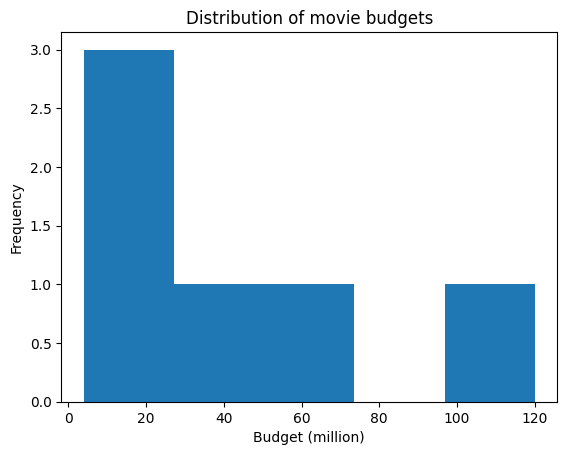

In [5]:
import matplotlib.pyplot as plt

movies["budget_million"].plot(kind="hist", bins=5)
plt.xlabel("Budget (million)")
plt.title("Distribution of movie budgets")
plt.show()

Understanding the data comes first because the next preprocessing steps depend on what we have learned. A nominal category usually needs a different representation from an ordinal category, and a heavily skewed numerical variable with outliers may need a different scaling strategy from a roughly symmetric one.

## 2. Encoding categorical features

Most machine-learning algorithms operate on numbers. Categorical values such as `"Comedy"` or `"Drama"` therefore need to be converted into a numerical representation.

The important question is not simply *how to turn text into numbers*, but **what information the numerical representation implies**.

### 2.1 Why arbitrary integer codes can be misleading

Suppose we encode animal types as


$\text{cat}=0,\quad \text{dog}=1,\quad \text{fish}=2,\quad \text{bird}=3.$

This representation introduces an artificial ordering. It also suggests numerical distances: the difference between cat and bird is three times the difference between cat and dog.

For a **nominal** feature, neither interpretation is meaningful.

This is why simply assigning integers to unordered categories is usually not an appropriate representation for machine learning.

### 2.2 One-hot encoding for nominal features

**One-hot encoding** creates a separate binary feature for each category.

Instead of one column such as

| genre |
| --- |
| Comedy |
| Drama |
| Action |

we obtain columns such as

| genre_Action | genre_Comedy | genre_Drama |
| ---: | ---: | ---: |
| 0 | 1 | 0 |
| 0 | 0 | 1 |
| 1 | 0 | 0 |

No ordering between categories is introduced.

In [6]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)
genre_encoded = encoder.fit_transform(movies[["genre"]])

genre_encoded = pd.DataFrame(
    genre_encoded,
    columns=encoder.get_feature_names_out()
)

genre_encoded

,genre_Action,genre_Comedy,genre_Drama
0,0.0,1.0,0.0
1,0.0,0.0,1.0
2,0.0,1.0,0.0
3,1.0,0.0,0.0
4,0.0,0.0,1.0
5,1.0,0.0,0.0


The encoder has two distinct operations:

- `fit`: learn which categories exist in the training data;
- `transform`: use those learned categories to encode observations.

This distinction will become important when we discuss data leakage.

### 2.3 Ordinal encoding when order is meaningful

Some categories *do* have an order. Consider clothing sizes:

$XS < S < M < L < XL.$

An ordinal encoding can preserve this ordering:

$XS\rightarrow0,\quad S\rightarrow1,\quad M\rightarrow2,\quad L\rightarrow3,\quad XL\rightarrow4.$

The ordering is meaningful, although we should still be careful: the representation also makes adjacent levels appear equally spaced. Whether that assumption is appropriate depends on the context and the model.

In [7]:
from sklearn.preprocessing import OrdinalEncoder

sizes = pd.DataFrame({"size": ["S", "XL", "M", "XS", "L"]})

ordinal_encoder = OrdinalEncoder(
    categories=[["XS", "S", "M", "L", "XL"]]
)

sizes["size_encoded"] = ordinal_encoder.fit_transform(sizes[["size"]])
sizes

,size,size_encoded
0,S,1.0
1,XL,4.0
2,M,2.0
3,XS,0.0
4,L,3.0


### 2.4 Encoding increases the number of features

One-hot encoding is simple and useful, but a categorical feature with many unique categories can create many new columns.

For example, a feature with 200 categories can become roughly 200 binary features. This may:

- increase memory and computation;
- make the feature space sparse;
- increase model complexity;
- contribute to high dimensionality.

This does not make one-hot encoding wrong. It means that the number and meaning of categories should be part of the preprocessing decision.

### 2.5 Categories that were not seen during training

A practical issue appears when the test data contain a category that did not occur in the training data.

Scikit-learn can be instructed to handle such categories instead of raising an error:

In [8]:
safe_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

safe_encoder.fit(pd.DataFrame({"genre": ["Comedy", "Drama", "Action"]}))

new_movies = pd.DataFrame({"genre": ["Comedy", "Documentary"]})
safe_encoder.transform(new_movies)

array([[0., 1., 0.],
       [0., 0., 0.]])

The unseen category `"Documentary"` becomes all zeros for the known genre columns. Whether this is acceptable depends on the application, but the important point is that preprocessing should also define what happens to future data.

> **Key idea:** encoding is a modelling decision. The numerical representation should reflect what is known about the variable, rather than merely converting strings into numbers.

## 3. Scaling numerical features

Consider two numerical features:

- age: values around 18–80;
- annual income: values around 20,000–100,000.

The income feature has numerically much larger values, but that does not necessarily mean it should have more influence on a model.

**Feature scaling** changes the numerical scale of a variable while preserving its relative information.

### 3.1 When does scale matter?

Scaling is especially important when the learning algorithm depends on:

- **distances**, as in k-nearest neighbours or k-means;
- **gradients**, where differently scaled features can make optimisation inefficient;
- **regularisation**, where coefficient penalties depend on coefficient magnitudes.

Tree-based methods such as decision trees and random forests are generally much less sensitive to feature scale because they split variables based on thresholds rather than distances.

So scaling is not a universal rule that must be applied before every model.

### 3.2 Min-max scaling

Min-max scaling maps a feature to a chosen interval, commonly \([0,1]\):

$x'=\frac{x-\min(x)}{\max(x)-\min(x)}.$

It preserves the relative position of observations between the minimum and maximum.

In [9]:
from sklearn.preprocessing import MinMaxScaler

x = pd.DataFrame({"value": [10, 20, 30, 40, 50]})

minmax = MinMaxScaler()
x["minmax"] = minmax.fit_transform(x[["value"]])
x

,value,minmax
0,10,0.00
1,20,0.25
2,30,0.50
3,40,0.75
4,50,1.00


Min-max scaling can be useful when a bounded range is desirable. However, because the minimum and maximum determine the transformation, extreme observations can strongly affect where the remaining values are placed.

### 3.3 Standardisation

Standardisation subtracts the mean and divides by the standard deviation:

$x'=\frac{x-\mu}{\sigma}.$

After transformation, the training feature has mean approximately 0 and standard deviation approximately 1.

In [10]:
from sklearn.preprocessing import StandardScaler

standard = StandardScaler()
x["standardized"] = standard.fit_transform(x[["value"]])
x

,value,minmax,standardized
0,10,0.00,-1.414214
1,20,0.25,-0.707107
2,30,0.50,0.000000
3,40,0.75,0.707107
4,50,1.00,1.414214


Standardisation is a common default for algorithms that are sensitive to feature scale. It does **not** make a variable normally distributed. It only changes its centre and scale.

### 3.4 Robust scaling and outliers

When a feature contains substantial outliers, the mean and standard deviation themselves can be strongly affected.

A **robust scaler** instead uses the median and interquartile range:

$x'=\frac{x-\operatorname{median}(x)}
{Q_{0.75}(x)-Q_{0.25}(x)}.$

This makes the transformation less sensitive to extreme values.

In [11]:
from sklearn.preprocessing import RobustScaler

with_outlier = pd.DataFrame({
    "value": [10, 11, 12, 13, 14, 100]
})

with_outlier["standardized"] = StandardScaler().fit_transform(
    with_outlier[["value"]]
)
with_outlier["robust_scaled"] = RobustScaler().fit_transform(
    with_outlier[["value"]]
)

with_outlier

,value,standardized,robust_scaled
0,10,-0.507804,-1.0
1,11,-0.477336,-0.6
2,12,-0.446867,-0.2
3,13,-0.416399,0.2
4,14,-0.385931,0.6
5,100,2.234337,35.0


The outlier is still an outlier after robust scaling. Robust scaling does **not remove** unusual observations; it simply prevents them from determining the centre and scale as strongly.

This distinction is important: scaling and outlier handling are different preprocessing decisions.

### 3.5 Choosing a scaler

There is no single scaler that is best in all situations.

| Method | Main idea | Particularly useful when |
| --- | --- | --- |
| Min-max scaling | Map values to a fixed range | A bounded range is useful |
| Standardisation | Centre by mean, scale by standard deviation | A scale-sensitive model is used |
| Robust scaling | Centre by median, scale by IQR | Strong outliers are present |

The appropriate choice depends both on the data distribution and on the model.

## 4. Feature selection and reducing redundancy

More features do not automatically produce a better model.

Additional features can increase computational cost, make models harder to interpret, and create opportunities to fit noise rather than useful signal. In high-dimensional spaces, observations can also become increasingly sparse and notions such as "nearby" can become less informative. This is one aspect of the **curse of dimensionality**.

Feature selection aims to retain useful features while removing features that add little information.

### 4.1 Low-variance features

A feature that is almost constant across all observations contains little information for distinguishing observations.

One simple strategy is **variance thresholding**, which removes numerical features whose variance is below a chosen threshold.

In [12]:
from sklearn.feature_selection import VarianceThreshold

example = pd.DataFrame({
    "almost_constant": [1, 1, 1, 1, 1, 2],
    "varying_feature": [2, 5, 1, 8, 3, 9]
})

selector = VarianceThreshold(threshold=0.2)
selected = selector.fit_transform(example)

example.var(), selector.get_support()

(almost_constant     0.166667
 varying_feature    10.666667
 dtype: float64,
 array([False,  True]))

The threshold itself has no universally correct value. It depends on how a feature is represented and scaled.

This leads to an important preprocessing interaction:

> If every feature is first standardised to variance 1, variance thresholding can no longer distinguish originally low-variance from high-variance features.

The **order** of preprocessing steps can therefore change what a method means.

### 4.2 Redundant features

Two features can both vary substantially while still carrying almost the same information.

For example, temperatures measured in Celsius and Fahrenheit are perfectly redundant. More realistically, two measurements may be strongly correlated because they capture closely related quantities.

In [13]:
redundant = pd.DataFrame({
    "feature_a": [1, 2, 3, 4, 5, 6],
    "feature_b": [2.1, 4.0, 6.2, 7.9, 10.1, 12.0],
    "feature_c": [7, 2, 9, 1, 8, 4]
})

redundant.corr()

,feature_a,feature_b,feature_c
feature_a,1.000000,0.999628,-0.080705
feature_b,0.999628,1.000000,-0.054441
feature_c,-0.080705,-0.054441,1.000000


Correlation can be a useful diagnostic for numerical features, but it is not a complete feature-selection strategy. A high correlation does not tell us automatically which feature should be removed, and low pairwise correlations do not guarantee that a feature is useful for prediction.

Feature selection methods can broadly use:

- properties of the features themselves, such as variance;
- relationships between features, such as redundancy;
- relationships between features and the target;
- model-based criteria.

In this chapter we focus on the intuition behind the first two. More advanced selection methods are closely connected to model evaluation and will be easier to understand after we have introduced predictive models.

### 4.3 Feature selection is not dimensionality reduction

Feature selection **keeps a subset of the original features**.

Dimensionality-reduction methods such as principal component analysis instead **construct new features** from combinations of the original ones.

The distinction matters for interpretation: after feature selection we can still talk about the original variables, while transformed dimensions may no longer have such a direct meaning.

## 5. Preprocessing without data leakage

So far, we have used `fit_transform` on complete toy datasets for illustration. In a real machine-learning workflow, this can be dangerous.

The test set is intended to represent data that the model has **not seen** during training. If information from the test set influences preprocessing, the evaluation is no longer fully independent. This is called **data leakage**.

### 5.1 Why fitting preprocessing on all data is a problem

Suppose we standardise a feature using the mean and standard deviation calculated from the entire dataset, and only afterwards split the data into training and test sets.

The transformation applied to the training observations has now used information from the test observations.

The same issue occurs when we:

- learn category levels from the full dataset;
- calculate scaling parameters from the full dataset;
- select features using all observations;
- impute missing values using statistics calculated from the full dataset.

The correct general rule is:

1. split the data;
2. **fit** preprocessing only on the training data;
3. use the fitted transformation to **transform** both training and test data.

In [14]:
from sklearn.model_selection import train_test_split

X = movies[[
    "runtime",
    "genre",
    "production_country",
    "budget_million"
]]
y = movies["revenue_million"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.33,
    random_state=42
)

X_train

,runtime,genre,production_country,budget_million
5,115,Action,UK,55.0
2,105,Comedy,UK,8.0
4,88,Drama,NL,6.0
3,140,Action,US,120.0


### 5.2 Different columns need different transformations

A realistic dataset usually contains both numerical and categorical features.

`ColumnTransformer` allows us to define different preprocessing for different groups of columns. For example:

- standardise numerical features;
- one-hot encode categorical features.

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = ["runtime", "budget_million"]
categorical_features = ["genre", "production_country"]

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

X_train_processed.shape, X_test_processed.shape

((4, 8), (2, 8))

Notice the asymmetry:

```python
preprocessor.fit_transform(X_train)
preprocessor.transform(X_test)
```

The preprocessing parameters are learned from the training set only. The test set is transformed using those already learned parameters.

### 5.3 Pipelines keep preprocessing and modelling together

A `Pipeline` combines preprocessing and a machine-learning model into a single workflow.

This is useful because the correct sequence is then applied consistently:

$\text{raw data}
\rightarrow
\text{preprocessing}
\rightarrow
\text{model}.
$

It also becomes much harder to accidentally preprocess the test set incorrectly.

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

model = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("regression", LinearRegression())
    ]
)

model.fit(X_train, y_train)
predictions = model.predict(X_test)

pd.DataFrame({
    "actual": y_test,
    "predicted": predictions
})

,actual,predicted
0,11.0,11.294577
1,64.0,99.906061


For this tiny artificial dataset, the predictions themselves are not meaningful. The purpose is the **workflow**: the pipeline learns both preprocessing and model parameters from the training data and applies the same fitted transformations when predicting new observations.

Pipelines become even more important when we later use cross-validation or compare several models.

## Summary

Preprocessing is not a fixed checklist. Each transformation should follow from the meaning of the data and the requirements of the model.

The main ideas from this chapter are:

- identify the meaning and type of each feature before transforming it;
- use one-hot encoding for nominal categories when an algorithm requires numerical input;
- use ordinal encoding only when an ordering is meaningful;
- scale numerical features when the model is sensitive to their numerical scale;
- choose the scaling method with the distribution and outliers in mind;
- remove features only for a clear reason, such as very low information or redundancy;
- remember that preprocessing steps can interact, so their order matters;
- fit all data-dependent preprocessing on the **training data only**;
- use `ColumnTransformer` and `Pipeline` to build a consistent and leakage-safe workflow.

A useful way to think about the complete process is:

$
\boxed{
\text{understand the data}
\rightarrow
\text{choose a representation}
\rightarrow
\text{transform appropriately}
\rightarrow
\text{fit the model}
}
$

The exercises accompanying this chapter focus on applying these ideas to less simplified datasets and making the preprocessing decisions yourself.